In [2]:
import json
import re
import matplotlib.pyplot as plt
import numpy as np
import sys
sys.path.insert(0, ".")
from script_2026_01_23_evaluate_biology_utility import classify_checkpoint_type, CheckpointType, extract_step_from_checkpoint_path

# Load results
with open("biology_utility_cache.json", "r") as f:
    data = json.load(f)

results = data["results"]

/mnt/align4_drive2/adrianoh/miniconda3/envs/scopebench/lib/python3.12/site-packages/beartype/_util/hint/pep/utilpeptest.py:339: BeartypeDecorHintPep585DeprecationWarning: PEP 484 type hint typing.Callable[[int], float] deprecated by PEP 585. This hint is scheduled for removal in the first Python version released after October 5th, 2025. To resolve this, import this hint from "beartype.typing" rather than "typing". For further commentary and alternatives, see also:
    https://beartype.readthedocs.io/en/latest/api_roar/#pep-585-deprecations
  warn(
/mnt/align4_drive2/adrianoh/miniconda3/envs/scopebench/lib/python3.12/site-packages/beartype/_util/hint/pep/utilpeptest.py:339: BeartypeDecorHintPep585DeprecationWarning: PEP 484 type hint typing.Callable deprecated by PEP 585. This hint is scheduled for removal in the first Python version released after October 5th, 2025. To resolve this, import this hint from "beartype.typing" rather than "typing". For further commentary and alternatives, s

In [3]:
# Extract (label, checkpoint_type, step, h_value, utility) tuples
def format_h_label(h: float) -> str:
    """Format h value nicely for display."""
    if h == 0:
        return "h=0"
    elif h < 1e-4:
        return f"h={h:.0e}"
    else:
        return f"h={h:.1e}" if h < 0.01 else f"h={h:.4f}".rstrip('0').rstrip('.')

entries = []
for r in results:
    kwargs = r["kwargs"]
    utility = r["data_dict"]["utility/overall"]
    
    checkpoint_type = classify_checkpoint_type(
        kwargs["model_name_or_path"],
        kwargs["pruned_sae_dist_path"]
    )
    
    if checkpoint_type == CheckpointType.VANILLA:
        entries.append(("Gemma2 (vanilla)", checkpoint_type, 0, float("inf"), utility))
    elif checkpoint_type == CheckpointType.SFT:
        # Extract step from path like /checkpoint-1000
        step = extract_step_from_checkpoint_path(kwargs["model_name_or_path"])
        entries.append((f"SFT step-{step}", checkpoint_type, step, float("inf"), utility))
    else:  # SAE_ENHANCED
        h = kwargs["pruned_sae_threshold"]
        label = format_h_label(h)
        entries.append((label, checkpoint_type, 0, h, utility))

# Sort: SFT (highest step first) -> Vanilla -> SAE-enhanced (by h ascending)
def sort_key(entry):
    label, checkpoint_type, step, h, utility = entry
    if checkpoint_type == CheckpointType.SFT:
        return (0, -step, 0)  # Group 0, higher step first
    elif checkpoint_type == CheckpointType.VANILLA:
        return (1, 0, 0)  # Group 1
    else:  # SAE_ENHANCED
        return (2, 0, h)  # Group 2, sorted by h

entries.sort(key=sort_key)

labels = [e[0] for e in entries]
utilities = [e[4] for e in entries]

print("Sorted entries:")
for label, ctype, step, h, u in entries:
    print(f"  {label} ({ctype.value}): utility={u:.4f}")

Sorted entries:
  Gemma2 (vanilla) (vanilla): utility=0.7444
  h=0 (sae_enhanced): utility=0.7444
  h=1e-08 (sae_enhanced): utility=0.8222
  h=1e-07 (sae_enhanced): utility=0.7778
  h=1e-06 (sae_enhanced): utility=0.7889
  h=1e-05 (sae_enhanced): utility=0.7556
  h=1.0e-04 (sae_enhanced): utility=0.7556
  h=1.0e-04 (sae_enhanced): utility=0.6889
  h=2.0e-04 (sae_enhanced): utility=0.6889
  h=3.0e-04 (sae_enhanced): utility=0.6222
  h=4.0e-04 (sae_enhanced): utility=0.3778
  h=5.0e-04 (sae_enhanced): utility=0.2000
  h=6.0e-04 (sae_enhanced): utility=0.0444
  h=7.0e-04 (sae_enhanced): utility=0.0333
  h=8.0e-04 (sae_enhanced): utility=0.0000
  h=9.0e-04 (sae_enhanced): utility=0.0111
  h=1.0e-03 (sae_enhanced): utility=0.0000
  h=4.5e-03 (sae_enhanced): utility=0.0000


In [4]:
# Print all checkpoint directories grouped by type for verification
sft_paths = []
gemma_paths = []
sae_paths = []

for r in results:
    kwargs = r["kwargs"]
    model_path = kwargs["model_name_or_path"]
    sae_path = kwargs["pruned_sae_dist_path"]
    
    checkpoint_type = classify_checkpoint_type(model_path, sae_path)
    
    if checkpoint_type == CheckpointType.SFT:
        sft_paths.append(model_path)
    elif checkpoint_type == CheckpointType.VANILLA:
        gemma_paths.append(model_path)
    else:  # SAE_ENHANCED
        sae_paths.append((model_path, sae_path, kwargs.get("pruned_sae_threshold", None)))

# Sort SFT paths by step number
sft_paths.sort(key=lambda p: extract_step_from_checkpoint_path(p))

# Sort SAE paths by threshold
sae_paths.sort(key=lambda x: x[2] if x[2] is not None else 0)

print("=== Checkpoint Directory Classification ===\n")

print("--- SFT Checkpoints ---")
for path in sft_paths:
    print(f"[SFT] {path}")
if not sft_paths:
    print("(none)")

print("\n--- GEMMA (Vanilla) Checkpoints ---")
for path in gemma_paths:
    print(f"[GEMMA] {path}")
if not gemma_paths:
    print("(none)")

print("\n--- SAE-Enhanced Checkpoints ---")
for model_path, sae_path, threshold in sae_paths:
    print(f"[SAE] model={model_path}, sae={sae_path}, h={threshold}")

=== Checkpoint Directory Classification ===

--- SFT Checkpoints ---
(none)

--- GEMMA (Vanilla) Checkpoints ---
[GEMMA] google/gemma-2-9b-it

--- SAE-Enhanced Checkpoints ---
[SAE] model=/mnt/align4_drive2/adrianoh/git/SAEScoping/experiments/outputs_gemma9b_h_sweep_2026_01_20/outputs_gemma9b/biology/model_layers_31_h0.0/outputs/checkpoint-2000, sae=/mnt/align4_drive2/adrianoh/git/ScopeBench/sae_training/deleteme_cache_bio_only/ignore_padding_True/biology/layer_31--width_16k--canonical/distribution.safetensors, h=0.0
[SAE] model=/mnt/align4_drive2/adrianoh/git/SAEScoping/experiments/outputs_gemma9b_h_sweep_2026_01_20/outputs_gemma9b/biology/model_layers_31_h1e-08/outputs/checkpoint-2000, sae=/mnt/align4_drive2/adrianoh/git/ScopeBench/sae_training/deleteme_cache_bio_only/ignore_padding_True/biology/layer_31--width_16k--canonical/distribution.safetensors, h=1e-08
[SAE] model=/mnt/align4_drive2/adrianoh/git/SAEScoping/experiments/outputs_gemma9b_h_sweep_2026_01_20/outputs_gemma9b/biology/

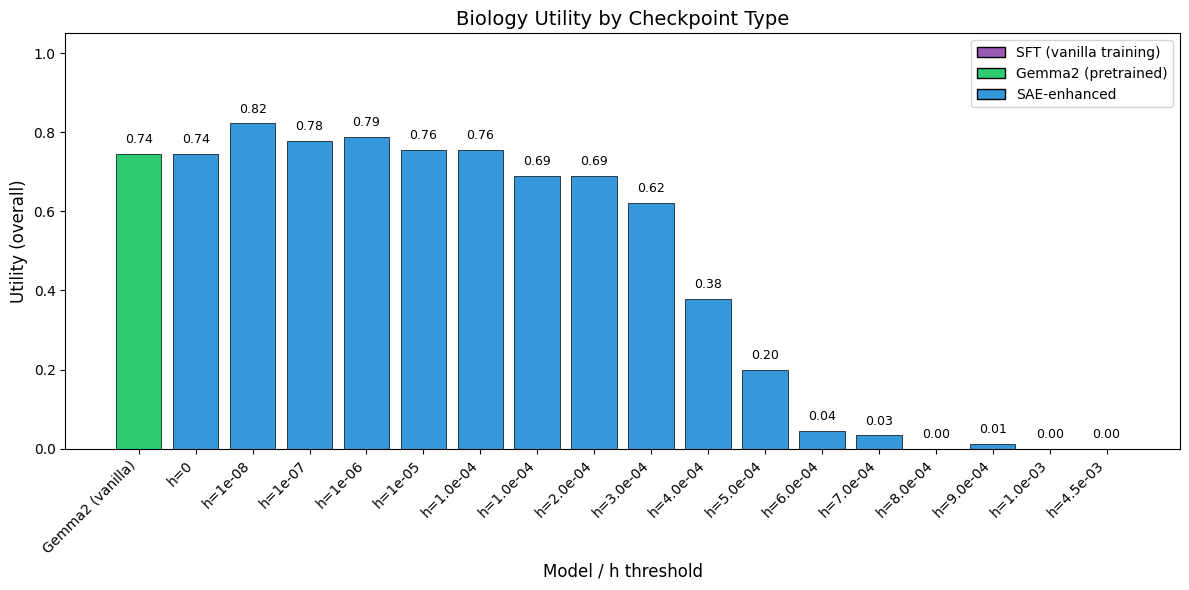

In [5]:
# Create bar chart
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(labels))

# Color by checkpoint type: purple for SFT, green for vanilla, blue for SAE-enhanced
colors = []
for label, checkpoint_type, step, h, utility in entries:
    if checkpoint_type == CheckpointType.SFT:
        colors.append("#9b59b6")  # Purple
    elif checkpoint_type == CheckpointType.VANILLA:
        colors.append("#2ecc71")  # Green
    else:  # SAE_ENHANCED
        colors.append("#3498db")  # Blue

bars = ax.bar(x, utilities, color=colors, edgecolor="black", linewidth=0.5)

ax.set_xlabel("Model / h threshold", fontsize=12)
ax.set_ylabel("Utility (overall)", fontsize=12)
ax.set_title("Biology Utility by Checkpoint Type", fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, ha="right")
ax.set_ylim(0, 1.05)

# Add value labels on bars
for bar, val in zip(bars, utilities):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
            f"{val:.2f}", ha="center", va="bottom", fontsize=9)

# Add legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#9b59b6", edgecolor="black", label="SFT (vanilla training)"),
    Patch(facecolor="#2ecc71", edgecolor="black", label="Gemma2 (pretrained)"),
    Patch(facecolor="#3498db", edgecolor="black", label="SAE-enhanced"),
]
ax.legend(handles=legend_elements, loc="upper right")

plt.tight_layout()
plt.savefig("biology_utility_barchart.png", dpi=150)
plt.show()

In [ ]:
# Print all checkpoint directories grouped by type for verification; some claude-generated stuff here
sft_paths = []
gemma_paths = []
sae_paths = []

for r in results:
    kwargs = r["kwargs"]
    model_path = kwargs["model_name_or_path"]
    sae_path = kwargs["pruned_sae_dist_path"]
    
    checkpoint_type = classify_checkpoint_type(model_path, sae_path)
    
    if checkpoint_type == CheckpointType.SFT:
        sft_paths.append(model_path)
    elif checkpoint_type == CheckpointType.VANILLA:
        gemma_paths.append(model_path)
    else:  # SAE_ENHANCED
        sae_paths.append((model_path, sae_path, kwargs.get("pruned_sae_threshold", None)))

# Sort SFT paths by step number
sft_paths.sort(key=lambda p: extract_step_from_checkpoint_path(p))

# Sort SAE paths by threshold
sae_paths.sort(key=lambda x: x[2] if x[2] is not None else 0)

print("=== Checkpoint Directory Classification ===\n")

print("--- SFT Checkpoints ---")
for path in sft_paths:
    print(f"[SFT] {path}")
if not sft_paths:
    print("(none)")

print("\n--- GEMMA (Vanilla) Checkpoints ---")
for path in gemma_paths:
    print(f"[GEMMA] {path}")
if not gemma_paths:
    print("(none)")

print("\n--- SAE-Enhanced Checkpoints ---")
for model_path, sae_path, threshold in sae_paths:
    print(f"[SAE] model={model_path}, sae={sae_path}, h={threshold}")

=== Checkpoint Directory Classification ===

--- SFT Checkpoints ---
(none)

--- GEMMA (Vanilla) Checkpoints ---
[GEMMA] google/gemma-2-9b-it

--- SAE-Enhanced Checkpoints ---
[SAE] model=/mnt/align4_drive2/adrianoh/git/SAEScoping/experiments/outputs_gemma9b_h_sweep_2026_01_20/outputs_gemma9b/biology/model_layers_31_h0.0/outputs/checkpoint-2000, sae=/mnt/align4_drive2/adrianoh/git/ScopeBench/sae_training/deleteme_cache_bio_only/ignore_padding_True/biology/layer_31--width_16k--canonical/distribution.safetensors, h=0.0
[SAE] model=/mnt/align4_drive2/adrianoh/git/SAEScoping/experiments/outputs_gemma9b_h_sweep_2026_01_20/outputs_gemma9b/biology/model_layers_31_h1e-08/outputs/checkpoint-2000, sae=/mnt/align4_drive2/adrianoh/git/ScopeBench/sae_training/deleteme_cache_bio_only/ignore_padding_True/biology/layer_31--width_16k--canonical/distribution.safetensors, h=1e-08
[SAE] model=/mnt/align4_drive2/adrianoh/git/SAEScoping/experiments/outputs_gemma9b_h_sweep_2026_01_20/outputs_gemma9b/biology/